<a href="https://www.kaggle.com/code/akramlaamari/toon239d687cce?scriptVersionId=294414008" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# # 1. Install critical libraries and update pip
# !pip install -U pip -q

# # 2. Fix the specific conflicts causing your error
# # We pin protobuf to 3.20.x to fix the 'MessageFactory' error
# # We pin pyarrow to <15.0 to fix the Kaggle cudf conflict
# !pip install "protobuf<=3.20.3" "pyarrow<15.0.0" -q

# # 3. Install your required libraries
# !pip install toml transformers[torch] datasets accelerate -q



In [2]:
import pandas as pd
import numpy as np
import os
import toml
import torch
import sys
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from datasets import Dataset
from tqdm.auto import tqdm
from transformers import (
    AutoConfig,
    AutoTokenizer, 
    AutoModelForSeq2SeqLM, 
    DataCollatorForSeq2Seq, 
    Seq2SeqTrainingArguments, 
    Seq2SeqTrainer,
    EarlyStoppingCallback
)

from sklearn.metrics import roc_curve, auc
import torch.nn.functional as F


2026-01-27 20:01:24.234641: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769544084.426323      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769544084.480973      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769544084.920236      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769544084.920278      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769544084.920280      24 computation_placer.cc:177] computation placer alr

In [3]:
# ############################################################### THe SOlid WAY
# # PHASE 1: ETL RIGOUREUX (Anti-Fuite de Données)
# #
# # 1. Chargement & Nettoyage
# # 2. Mapping (Super-Classes)
# # 3. SPLIT (Train/Val/Test) --> CRUCIAL : AVANT L'ÉQUILIBRAGE
# # 4. Équilibrage (Uniquement sur le TRAIN)
# # 5. Conversion & Sauvegarde
# ###############################################################

# import pandas as pd
# import numpy as np
# import os
# import toml
# from sklearn.model_selection import train_test_split
# from sklearn.utils import resample
# from tqdm.auto import tqdm  # Bibliothèque pour la barre de progression

# print("===== Démarrage Phase 1 (ETL Sécurisé & Barre de Progression) =====")

# # --- 1. CONFIGURATION ---
# # ⚠️ ADAPTER SELON VOTRE ENVIRONNEMENT (KAGGLE ou COLAB)
# # Exemple Kaggle :
# DATA_DIR = "/kaggle/input/cc20218/CSE-CIC-IDS2018/"
# SAVE_DIR = "/kaggle/working/Toonset/"

# # Exemple Colab (décommenter si besoin) :
# # DATA_DIR = "/content/drive/MyDrive/LLM/CSE-CIC-IDS2018/CSE-CIC-IDS2018/"
# # SAVE_DIR = "/content/drive/MyDrive/LLM/Toon_Full_Dataset/"

# TRAIN_FILE = os.path.join(SAVE_DIR, 'train_full.toon')
# VALIDATION_FILE = os.path.join(SAVE_DIR, 'validation_full.toon')
# TEST_FILE = os.path.join(SAVE_DIR, 'test_full.toon')

# os.makedirs(SAVE_DIR, exist_ok=True)

# # Liste des fichiers
# ALL_FILES = [
#     "Bot.csv", "Brute Force -Web.csv", "Brute Force -XSS.csv",
#     "DDOS attack-HOIC.csv", "DDOS attack-LOIC-UDP.csv", "DDoS attacks-LOIC-HTTP.csv",
#     "DoS attacks-GoldenEye.csv", "DoS attacks-Hulk.csv", "DoS attacks-SlowHTTPTest.csv",
#     "DoS attacks-Slowloris.csv", "FTP-BruteForce.csv", "Infilteration.csv",
#     "SQL Injection.csv", "SSH-Bruteforce.csv"
# ]

# # Mapping des Classes (7 Super-Classes)
# LABEL_MAPPING = {
#     "Benign": "Benign",
#     "Bot": "Bot",
#     "DDOS attack-HOIC": "DDoS", "DDOS attack-LOIC-UDP": "DDoS", "DDoS attacks-LOIC-HTTP": "DDoS",
#     "DoS attacks-GoldenEye": "DoS", "DoS attacks-Hulk": "DoS", "DoS attacks-SlowHTTPTest": "DoS", "DoS attacks-Slowloris": "DoS",
#     "FTP-BruteForce": "BruteForce", "SSH-Bruteforce": "BruteForce",
#     "Brute Force -Web": "Web", "Brute Force -XSS": "Web", "SQL Injection": "Web",
#     "Infilteration": "Infiltration"
# }

# MIN_SAMPLES_TRAIN = 5000  # Seuil pour l'oversampling du TRAIN uniquement

# # --- 2. FONCTIONS DE TRAITEMENT ---

# def clean_and_map_df(df):
#     """Nettoie, renomme les colonnes et applique le mapping."""
#     # Nettoyage valeurs
#     df.replace([np.inf, -np.inf], np.nan, inplace=True)
#     df.fillna(0, inplace=True)
    
#     # Standardisation colonnes
#     df.columns = [c.strip().replace(' ', '_').replace('/', '_').upper() for c in df.columns]

#     # Renommage Label
#     if 'LABEL' not in df.columns:
#         for col in df.columns:
#             if "LABEL" in col:
#                 df.rename(columns={col: 'LABEL'}, inplace=True)
#                 break
    
#     if 'LABEL' not in df.columns: return None, None

#     # Suppression métadonnées
#     cols_to_drop = ['FLOW_ID', 'SRC_IP', 'SRC_PORT', 'DST_IP', 'TIMESTAMP', 'DATE']
#     df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True, errors='ignore')

#     # Mapping Super-Classes
#     df['LABEL'] = df['LABEL'].map(LABEL_MAPPING).fillna("Other")
#     df = df[df['LABEL'] != "Other"] # On retire les labels inconnus

#     features = [col for col in df.columns if col != 'LABEL']
#     return df, features

# def create_toon_entries(df, features):
#     """Convertit un DataFrame en liste de dictionnaires TOON rapidement."""
#     # Utilisation de zip pour aller très vite sans apply()
#     # On convertit tout en string d'un coup
#     input_data = df[features].astype(str).values.tolist()
#     target_data = df['LABEL'].astype(str).tolist()
    
#     entries = []
#     # Join avec "|"
#     for row, target in zip(input_data, target_data):
#         entries.append({
#             "input": "|".join(row),
#             "target": target
#         })
#     return entries

# def balance_training_data(df):
#     """Logique d'équilibrage appliquée UNIQUEMENT au Train set."""
#     balanced_chunks = []
#     unique_labels = df['LABEL'].unique()
    
#     print(f"   ... Équilibrage des classes : {unique_labels}")
    
#     for label in unique_labels:
#         sub = df[df['LABEL'] == label]
#         count = len(sub)
        
#         if label == "Benign":
#             # Undersampling Benign (20%)
#             sub = sub.sample(frac=0.2, random_state=42)
#         elif count < MIN_SAMPLES_TRAIN:
#             # Oversampling Rare (xN jusqu'à 5000)
#             sub = resample(sub, replace=True, n_samples=MIN_SAMPLES_TRAIN, random_state=42)
        
#         balanced_chunks.append(sub)
        
#     return pd.concat(balanced_chunks)

# # --- 3. EXÉCUTION PRINCIPALE ---

# def run_phase_1():
#     # 1. Chargement global
#     all_dfs = []
#     final_features = []
    
#     print("--- 1. Lecture des Fichiers ---")
#     # TQDM pour la barre de progression des fichiers
#     for filename in tqdm(ALL_FILES, desc="Loading CSVs"):
#         path = os.path.join(DATA_DIR, filename)
#         if not os.path.exists(path): continue
        
#         try:
#             # Lecture partielle si mémoire limitée (sinon tout lire)
#             df = pd.read_csv(path, low_memory=False)
#             df, feats = clean_and_map_df(df)
            
#             if df is not None:
#                 all_dfs.append(df)
#                 if not final_features: final_features = feats
                
#         except Exception as e:
#             print(f"Erreur {filename}: {e}")

#     if not all_dfs:
#         print("Erreur: Aucune donnée chargée.")
#         return

#     # Fusion
#     full_df = pd.concat(all_dfs, ignore_index=True)
#     print(f"Total Données Brutes : {len(full_df)} lignes")
    
#     # 2. SPLIT STRICT (Avant équilibrage !)
#     # On sépare d'abord le TEST (20%) qui doit rester 'Puir' (Distribution réelle)
#     print("--- 2. Split Train/Test (Stratifié) ---")
#     train_val_df, test_df = train_test_split(full_df, test_size=0.2, stratify=full_df['LABEL'], random_state=42)
    
#     # On sépare ensuite Train et Validation
#     train_df, val_df = train_test_split(train_val_df, test_size=0.2, stratify=train_val_df['LABEL'], random_state=42)
    
#     # Libération mémoire
#     del full_df, train_val_df, all_dfs
    
#     # 3. ÉQUILIBRAGE (Uniquement sur TRAIN)
#     print("--- 3. Équilibrage (Train uniquement) ---")
#     train_df_balanced = balance_training_data(train_df)
    
#     print(f"   -> Train (Balanced): {len(train_df_balanced)} | Val (Pure): {len(val_df)} | Test (Pure): {len(test_df)}")

#     # 4. CONVERSION ET SAUVEGARDE
#     print("--- 4. Conversion et Sauvegarde ---")
    
#     datasets = [
#         ("TRAIN", train_df_balanced, TRAIN_FILE),
#         ("VALIDATION", val_df, VALIDATION_FILE),
#         ("TEST", test_df, TEST_FILE)
#     ]
    
#     for name, df, filepath in datasets:
#         print(f"   Traitement {name}...")
#         # Conversion rapide
#         entries = create_toon_entries(df, final_features)
        
#         # Sauvegarde
#         with open(filepath, 'w', encoding='utf-8') as f:
#             toml.dump({"entry": entries}, f)
#         print(f"   ✅ {name} sauvegardé dans {filepath}")

# if __name__ == "__main__":
#     # run_phase_1()

In [4]:
# ###############################################################
# # PHASE 1: ETL "EXPERT AGENT" (Sémantique + Log-Norm + Hiérarchie)
# #
# # Améliorations PhD :
# # 1. SPLIT D'ABORD : Garantit l'intégrité scientifique (Anti-Fuite).
# # 2. LOG-NORMALIZATION : Compresse les données (Bytes/Duration) pour T5.
# # 3. SEMANTIC PREFIXES : Ajoute "dp_", "dur_" (Input Context).
# # 4. HIERARCHICAL TARGETS : Cibles "Chain-of-Thought" (Output Reasoning).
# ###############################################################

# import pandas as pd
# import numpy as np
# import os
# import toml
# from sklearn.model_selection import train_test_split
# from sklearn.utils import resample
# from tqdm.auto import tqdm

# print("===== Démarrage Phase 1 (Mode Expert : CoT + Sémantique) =====")

# # --- 1. CONFIGURATION ---
# DATA_DIR = "/kaggle/input/cc20218/CSE-CIC-IDS2018/"
# SAVE_DIR = "/kaggle/working/Toonset/"

# TRAIN_FILE = os.path.join(SAVE_DIR, 'train_full.toon')
# VALIDATION_FILE = os.path.join(SAVE_DIR, 'validation_full.toon')
# TEST_FILE = os.path.join(SAVE_DIR, 'test_full.toon')

# os.makedirs(SAVE_DIR, exist_ok=True)

# ALL_FILES = [
#     "Bot.csv", "Brute Force -Web.csv", "Brute Force -XSS.csv",
#     "DDOS attack-HOIC.csv", "DDOS attack-LOIC-UDP.csv", "DDoS attacks-LOIC-HTTP.csv",
#     "DoS attacks-GoldenEye.csv", "DoS attacks-Hulk.csv", "DoS attacks-SlowHTTPTest.csv",
#     "DoS attacks-Slowloris.csv", "FTP-BruteForce.csv", "Infilteration.csv",
#     "SQL Injection.csv", "SSH-Bruteforce.csv"
# ]

# # 1. Mapping pour le nettoyage (Grouper les labels CSV bruts)
# LABEL_MAPPING = {
#     "Benign": "Benign",
#     "Bot": "Bot",
#     "DDOS attack-HOIC": "DDoS-HOIC", "DDOS attack-LOIC-UDP": "DDoS-LOIC-UDP", "DDoS attacks-LOIC-HTTP": "DDoS-LOIC-HTTP",
#     "DoS attacks-GoldenEye": "DoS-GoldenEye", "DoS attacks-Hulk": "DoS-Hulk", "DoS attacks-SlowHTTPTest": "DoS-SlowHTTP", "DoS attacks-Slowloris": "DoS-Slowloris",
#     "FTP-BruteForce": "BruteForce-FTP", "SSH-Bruteforce": "BruteForce-SSH",
#     "Brute Force -Web": "Web-Brute", "Brute Force -XSS": "Web-XSS", "SQL Injection": "Web-SQL",
#     "Infilteration": "Infiltration"
# }

# # 2. Mapping Hiérarchique (Chain-of-Thought pour le modèle)
# # Le modèle apprendra à générer cette chaîne de raisonnement.
# HIERARCHY_MAPPING = {
#     "Benign": "Benign > Normal > None",
#     "Bot": "Attack > Botnet > ARES",
#     "DDoS-HOIC": "Attack > DDoS > HOIC",
#     "DDoS-LOIC-UDP": "Attack > DDoS > LOIC-UDP",
#     "DDoS-LOIC-HTTP": "Attack > DDoS > LOIC-HTTP",
#     "DoS-GoldenEye": "Attack > DoS > GoldenEye",
#     "DoS-Hulk": "Attack > DoS > Hulk",
#     "DoS-SlowHTTP": "Attack > DoS > SlowHTTP",
#     "DoS-Slowloris": "Attack > DoS > Slowloris",
#     "BruteForce-FTP": "Attack > BruteForce > FTP",
#     "BruteForce-SSH": "Attack > BruteForce > SSH",
#     "Web-Brute": "Attack > Web > BruteWeb",
#     "Web-XSS": "Attack > Web > XSS",
#     "Web-SQL": "Attack > Web > SQLi",
#     "Infiltration": "Attack > Infiltration > Pivot"
# }

# MIN_SAMPLES_TRAIN = 5000 

# # --- 2. FONCTIONS INTELLIGENTES ---

# def clean_and_map_df(df):
#     """Nettoyage + Mapping + Log-Normalization"""
#     df.replace([np.inf, -np.inf], np.nan, inplace=True)
#     df.fillna(0, inplace=True)
#     df.columns = [c.strip().replace(' ', '_').replace('/', '_').upper() for c in df.columns]

#     if 'LABEL' not in df.columns:
#         for col in df.columns:
#             if "LABEL" in col:
#                 df.rename(columns={col: 'LABEL'}, inplace=True)
#                 break
#     if 'LABEL' not in df.columns: return None, None

#     cols_to_drop = ['FLOW_ID', 'SRC_IP', 'SRC_PORT', 'DST_IP', 'TIMESTAMP', 'DATE']
#     df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True, errors='ignore')

#     # Mapping Classes (Intermédiaire)
#     df['LABEL'] = df['LABEL'].map(LABEL_MAPPING).fillna("Other")
#     df = df[df['LABEL'] != "Other"]

#     # --- EXPERT TRICK : LOG NORMALIZATION ---
#     cols_to_log = [c for c in df.columns if any(x in c for x in ['BYTES', 'DURATION', 'LENGTH', 'PKTS', 'IAT'])]
    
#     for c in cols_to_log:
#         if pd.api.types.is_numeric_dtype(df[c]):
#             df[c] = np.log1p(df[c].clip(lower=0)).round(2)

#     features = [col for col in df.columns if col != 'LABEL']
#     return df, features

# def create_toon_entries(df, features):
#     """Conversion avec SEMANTIC PREFIXES + HIERARCHICAL TARGETS"""
    
#     # 1. Préfixes (Expert Indicators - Input)
#     col_prefixes = []
#     for col in features:
#         if "DST_PORT" in col: p = "dp_"
#         elif "PROTOCOL" in col: p = "pr_"
#         elif "DURATION" in col: p = "dur_"
#         elif "TOT" in col and "PKTS" in col: p = "cnt_"
#         elif "BYTES" in col: p = "by_"
#         elif "FLAGS" in col: p = "fl_"
#         elif "SIZE" in col: p = "sz_"
#         else: p = "v_"
#         col_prefixes.append(p)

#     data_values = df[features].astype(str).values
    
#     # 2. Cibles Hiérarchiques (Reasoning - Output)
#     # On transforme "DDoS-HOIC" en "Attack > DDoS > HOIC"
#     raw_labels = df['LABEL'].tolist()
#     targets = [HIERARCHY_MAPPING.get(l, f"Attack > Other > {l}") for l in raw_labels]
    
#     entries = []
    
#     # Création des entrées
#     for row, target in zip(data_values, targets):
#         # Input: "dp_80|dur_0.01|..."
#         tokenized_row = [f"{prefix}{val}" for prefix, val in zip(col_prefixes, row)]
        
#         entries.append({
#             "input": "|".join(tokenized_row),
#             "target": target
#         })
        
#     return entries

# def balance_training_data(df):
#     """Équilibrage (Uniquement Train)"""
#     balanced_chunks = []
#     unique_labels = df['LABEL'].unique()
    
#     print(f"   ... Équilibrage : {unique_labels}")
    
#     for label in unique_labels:
#         sub = df[df['LABEL'] == label]
#         count = len(sub)
        
#         if label == "Benign":
#             sub = sub.sample(frac=0.2, random_state=42)
#         elif count < MIN_SAMPLES_TRAIN:
#             # On oversample les classes rares pour qu'elles atteignent 5000
#             sub = resample(sub, replace=True, n_samples=MIN_SAMPLES_TRAIN, random_state=42)
        
#         balanced_chunks.append(sub)
        
#     return pd.concat(balanced_chunks)

# # --- 3. EXÉCUTION ---

# def run_phase_1():
#     all_dfs = []
#     final_features = []
    
#     print("--- 1. Lecture & Préparation Expert ---")
#     for filename in tqdm(ALL_FILES, desc="Processing CSVs"):
#         path = os.path.join(DATA_DIR, filename)
#         if not os.path.exists(path): continue
        
#         try:
#             df = pd.read_csv(path, low_memory=False)
#             df, feats = clean_and_map_df(df)
            
#             if df is not None:
#                 all_dfs.append(df)
#                 if not final_features: final_features = feats
#         except Exception as e:
#             print(f"Erreur {filename}: {e}")

#     if not all_dfs: return

#     full_df = pd.concat(all_dfs, ignore_index=True)
#     print(f"Total Données : {len(full_df)}")
    
#     # 2. SPLIT D'ABORD (Critique pour validité scientifique)
#     print("--- 2. Split Train/Test ---")
#     train_val_df, test_df = train_test_split(full_df, test_size=0.2, stratify=full_df['LABEL'], random_state=42)
#     train_df, val_df = train_test_split(train_val_df, test_size=0.2, stratify=train_val_df['LABEL'], random_state=42)
    
#     del full_df, train_val_df, all_dfs
    
#     # 3. ÉQUILIBRAGE (Train Seulement)
#     print("--- 3. Équilibrage Expert ---")
#     train_df_balanced = balance_training_data(train_df)
    
#     # 4. SAUVEGARDE
#     print("--- 4. Génération TOON (CoT + Prefixes) ---")
#     datasets = [("TRAIN", train_df_balanced, TRAIN_FILE), ("VAL", val_df, VALIDATION_FILE), ("TEST", test_df, TEST_FILE)]
    
#     for name, df, filepath in datasets:
#         entries = create_toon_entries(df, final_features)
#         with open(filepath, 'w', encoding='utf-8') as f:
#             toml.dump({"entry": entries}, f)
#         print(f"   ✅ {name} sauvegardé ({len(entries)} entrées)")

# if __name__ == "__main__":
#     run_phase_1()

In [5]:
# ###############################################################
# # PHASE 2: Entraînement T5 "Full Scale" (Avec Affichage)
# #
# # - Hardware : GPU Check.
# # - Scheduler : Cosine.
# # - Affichage : Barre de progression + Logs fréquents.
# ###############################################################


# # --- 1. CONFIGURATION ---
# MODEL_NAME = 'google/flan-t5-small'  # <--- LE CHANGEMENT MAJEUR

# # ⚡ TEST RAPIDE : 0.01 = 1% des données. Mettez 1.0 pour le vrai entraînement.
# SAMPLE_RATE = 0.01

# DATA_DIR = "/kaggle/input/smartset"  
# OUTPUT_DIR = "/kaggle/working/T5_Model_P100/"

# # Vérification GPU
# if torch.cuda.is_available():
#     print(f"✅ GPU DÉTECTÉ : {torch.cuda.get_device_name(0)}")
# else:
#     print("⚠️ ATTENTION : TRAIN SUR CPU (LENT)")

# # --- 2. CHARGEMENT (CORRIGÉ) ---
# # Ajout de l'argument 'sample_rate' dans la définition
# def load_dataset_toon(path, sample_rate=1.0):
#     print(f"Chargement {path}...")
#     try:
#         with open(path, 'r', encoding='utf-8') as f:
#             data = toml.load(f)
#     except FileNotFoundError:
#         print(f"❌ ERREUR: Fichier introuvable : {path}")
#         return None
    
#     ds = Dataset.from_list(data['entry']).rename_column("input", "input_text").rename_column("target", "target_text")

#     # --- LOGIQUE D'ÉCHANTILLONNAGE ---
#     if sample_rate < 1.0:
#         num_samples = int(len(ds) * sample_rate)
#         # On garde au moins 10 lignes pour éviter les crashs
#         num_samples = max(10, num_samples) 
#         ds = ds.shuffle(seed=42).select(range(num_samples))
#         print(f"   ⚠️ MODE TEST : Dataset réduit à {len(ds)} lignes ({sample_rate*100}%)")
#     else:
#         print(f"   -> Chargement complet ({len(ds)} lignes)")
#     # -----------------------------------

#     return ds

# # # --- 2. CHARGEMENT ---

# # Utilisation de vos noms de fichiers spécifiques
# print("--- Préparation des Données ---")
# # Maintenant l'appel fonctionne car la fonction accepte l'argument
# train_dataset = load_dataset_toon(os.path.join(DATA_DIR, 'train_full.toon'), sample_rate=SAMPLE_RATE)
# val_dataset = load_dataset_toon(os.path.join(DATA_DIR, 'validation_full.toon'), sample_rate=SAMPLE_RATE)

# if train_dataset is None or val_dataset is None:
#     sys.exit("Arrêt : Fichiers manquants.")
 

In [6]:

# # --- 3. TOKENIZATION (MODE CPU DOUX) ---
# tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
# MAX_IN = 512
# MAX_OUT = 32

# def process(examples):
#     inputs = tokenizer(examples["input_text"], max_length=MAX_IN, truncation=True, padding="max_length")
#     targets = tokenizer(examples["target_text"], max_length=MAX_OUT, truncation=True, padding="max_length")
#     inputs["labels"] = targets["input_ids"]
#     return inputs

# print("⏳ Tokenisation en cours")

# # On ajoute batch_size=1000 pour traiter par petits paquets
# train_tokenized = train_dataset.map(
#     process, 
#     batched=True, 
#     batch_size=1000, 
#     remove_columns=["input_text", "target_text"]
# )

# val_tokenized = val_dataset.map(
#     process, 
#     batched=True, 
#     batch_size=1000, 
#     remove_columns=["input_text", "target_text"]
# )

# print(" Tokenisation terminée ")


In [7]:

# # --- 4. MODÈLE & CONFIGURATION P100 ---
# print("Configuration du Dropout...")
# config = AutoConfig.from_pretrained(MODEL_NAME)

# config.dropout_rate = 0.1 

# model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME, config=config)
# data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model)

# # Configuration P100 (Pascal Architecture)
# training_args = Seq2SeqTrainingArguments(
#     output_dir=os.path.join(OUTPUT_DIR, "checkpoints"),
    
#     # --- Optimisation P100 ---
#     fp16=True,                       # ✅ OUI : P100 supporte très bien FP16
#     bf16=False,                      # ❌ NON : P100 ne supporte PAS BF16
#     tf32=False,                      # ❌ NON : P100 ne supporte PAS TF32
    
#     # --- Gestion Mémoire (CORRIGÉ POUR ÉVITER OOM) ---
#     per_device_train_batch_size=32,  # Réduit de 64 -> 32
#     gradient_accumulation_steps=2,   # Augmenté pour compenser (Batch effectif reste 64)
#     per_device_eval_batch_size=32,   # Réduit aussi pour l'eval
#     dataloader_num_workers=2,
    
#     # --- Stratégie d'Entraînement ---
#     learning_rate=3e-4,
#     num_train_epochs=3,
#     weight_decay=0.01,
#     lr_scheduler_type="cosine",
#     warmup_ratio=0.1,
    
#     # --- Logs & Save ---
#     logging_strategy="steps",
#     logging_steps=50,
#     eval_strategy="steps",
#     eval_steps=1000,
#     save_strategy="steps",
#     save_steps=1000,
#     save_total_limit=2,
#     load_best_model_at_end=True,
#     disable_tqdm=False,              # Barre de progression active
#     report_to="none"
# )

# # Nettoyage mémoire avant de commencer
# torch.cuda.empty_cache()

# trainer = Seq2SeqTrainer(
#     model=model,
#     args=training_args,
#     train_dataset=train_tokenized,
#     eval_dataset=val_tokenized,
#     tokenizer=tokenizer,
#     data_collator=data_collator,
#     callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
# )

# print("--- Lancement du Training sur P100 ---")
# trainer.train()

# final_path = os.path.join(OUTPUT_DIR, "Final")
# trainer.save_model(final_path)
# tokenizer.save_pretrained(final_path)
# print(f"✅ Modèle sauvegardé : {final_path}")

In [8]:
#trainer.train(resume_from_checkpoint=True)

In [9]:
# ###############################################################
# # PHASE 3: Évaluation Finale (Multi-Classe + Binaire)
# ###############################################################

# import toml
# import torch
# import seaborn as sns
# import matplotlib.pyplot as plt
# from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
# from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
# from tqdm import tqdm
# import numpy as np

# # --- CONFIGURATION ---
# # Assurez-vous que ces chemins correspondent à vos fichiers Kaggle
# MODEL_PATH = "/kaggle/working/T5_Model_P100/Final"
# TEST_FILE = "/kaggle/input/toon24/test_full (1).toon" 

# # IMPORTANT : Doit être identique à la PHASE 2 (256 ou 512)
# MAX_LEN = 512 
# BATCH_SIZE = 64
# DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# # --- 1. CHARGEMENT ---
# print(f"Chargement du modèle depuis {MODEL_PATH}...")
# try:
#     tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
#     model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_PATH).to(DEVICE)
#     model.eval()
# except Exception as e:
#     print(f"Erreur de chargement modèle : {e}")
#     exit()

# # --- 2. LECTURE DONNÉES ---
# print(f"Lecture du fichier test : {TEST_FILE}...")
# with open(TEST_FILE, 'r') as f:
#     data = toml.load(f)

# # Extraction des listes
# inputs = [d['input'] for d in data['entry']]
# targets = [d['target'] for d in data['entry']]

# # --- 3. INFÉRENCE (PRÉDICTIONS) ---
# preds = []
# print(f"Démarrage de l'évaluation sur {len(inputs)} échantillons...")

# # Boucle par batch (plus rapide que un par un)
# for i in tqdm(range(0, len(inputs), BATCH_SIZE)):
#     batch_input = inputs[i : i+BATCH_SIZE]
    
#     # Tokenization
#     tok = tokenizer(
#         batch_input, 
#         max_length=MAX_LEN, 
#         padding="max_length", 
#         truncation=True, 
#         return_tensors="pt"
#     ).to(DEVICE)

#     with torch.no_grad():
#         # Generation (Inference)
#         gen = model.generate(tok["input_ids"], max_length=16)

#     # Décodage (Token IDs -> Texte)
#     decoded = tokenizer.batch_decode(gen, skip_special_tokens=True)
#     preds.extend([p.strip() for p in decoded])

# # --- 4. RAPPORT DÉTAILLÉ (MULTI-CLASSES) ---
# print("\n" + "="*50)
# print("RAPPORT 1 : CLASSIFICATION DÉTAILLÉE (Type d'Attaque)")
# print("="*50)
# print(classification_report(targets, preds, zero_division=0))

# # Matrice de Confusion Détaillée
# plt.figure(figsize=(10, 8))
# labels = sorted(list(set(targets)))
# cm = confusion_matrix(targets, preds, labels=labels)
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
# plt.title("Matrice de Confusion : Types d'Attaques")
# plt.ylabel("Réel")
# plt.xlabel("Prédit")
# plt.show()

# # --- 5. RAPPORT BINAIRE (BENIGN vs ATTACK) ---
# print("\n" + "="*50)
# print("RAPPORT 2 : DÉTECTION BINAIRE (Benign vs Attack)")
# print("="*50)

# # Conversion logique : Tout ce qui n'est pas "Benign" devient "Attack"
# def to_binary(label_list):
#     return ["Benign" if x == "Benign" else "Attack" for x in label_list]

# binary_targets = to_binary(targets)
# binary_preds = to_binary(preds)

# # Calcul des métriques
# print(classification_report(binary_targets, binary_preds, zero_division=0))

# # Matrice de Confusion Binaire
# plt.figure(figsize=(6, 5))
# bin_labels = ["Benign", "Attack"]
# cm_bin = confusion_matrix(binary_targets, binary_preds, labels=bin_labels)
# sns.heatmap(cm_bin, annot=True, fmt='d', cmap='Reds', xticklabels=bin_labels, yticklabels=bin_labels)
# plt.title("Matrice de Confusion Binaire (Intrusion Detection)")
# plt.ylabel("Réel")
# plt.xlabel("Prédit")
# plt.show()

========== CONFIG ==========
DEVICE: cuda
GPU: Tesla P100-PCIE-16GB
MODEL_PATH: /kaggle/input/finalb
TEST_FILE: /kaggle/input/toon24/test_full (1).toon
SAMPLE_RATE: 1.0
BATCH_SIZE: 64

--- Chargement de l'Agent Expert ---
Lecture du fichier test : /kaggle/input/toon24/test_full (1).toon...
-> 1925030 scénarios de test chargés (100%).
Génération des analyses (Inférence)...


Inference (generate):   0%|          | 0/30079 [00:00<?, ?it/s]


████████████████████████████████████████████████████████████
RAPPORT NIVEAU 1 : DÉTECTION DE MENACES (BINAIRE)
████████████████████████████████████████████████████████████
              precision    recall  f1-score   support

      Benign       0.99      0.94      0.97   1375383
     Unknown       0.87      0.97      0.92    549647

    accuracy                           0.95   1925030
   macro avg       0.93      0.96      0.94   1925030
weighted avg       0.96      0.95      0.95   1925030



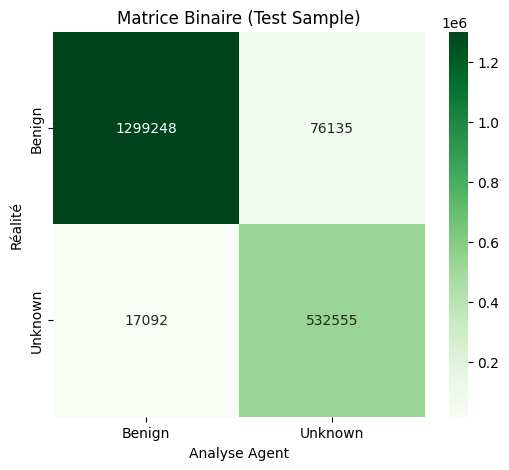


████████████████████████████████████████████████████████████
RAPPORT NIVEAU 2 : IDENTIFICATION PRÉCISE (Expertise)
████████████████████████████████████████████████████████████
Labels seen (Level-2): ['Benign', 'Botnet', 'BruteForce', 'DDoS', 'DoS', 'Infiltration', 'Web_Attack']
              precision    recall  f1-score   support

      Benign       0.99      0.94      0.97   1375383
      Botnet       0.99      1.00      0.99     57238
  BruteForce       0.84      0.97      0.90     76190
        DDoS       0.99      1.00      1.00    252787
         DoS       0.97      0.90      0.93    130860
Infiltration       0.18      0.48      0.26     32387
  Web_Attack       0.18      0.60      0.27       185

    accuracy                           0.94   1925030
   macro avg       0.73      0.84      0.76   1925030
weighted avg       0.97      0.94      0.95   1925030



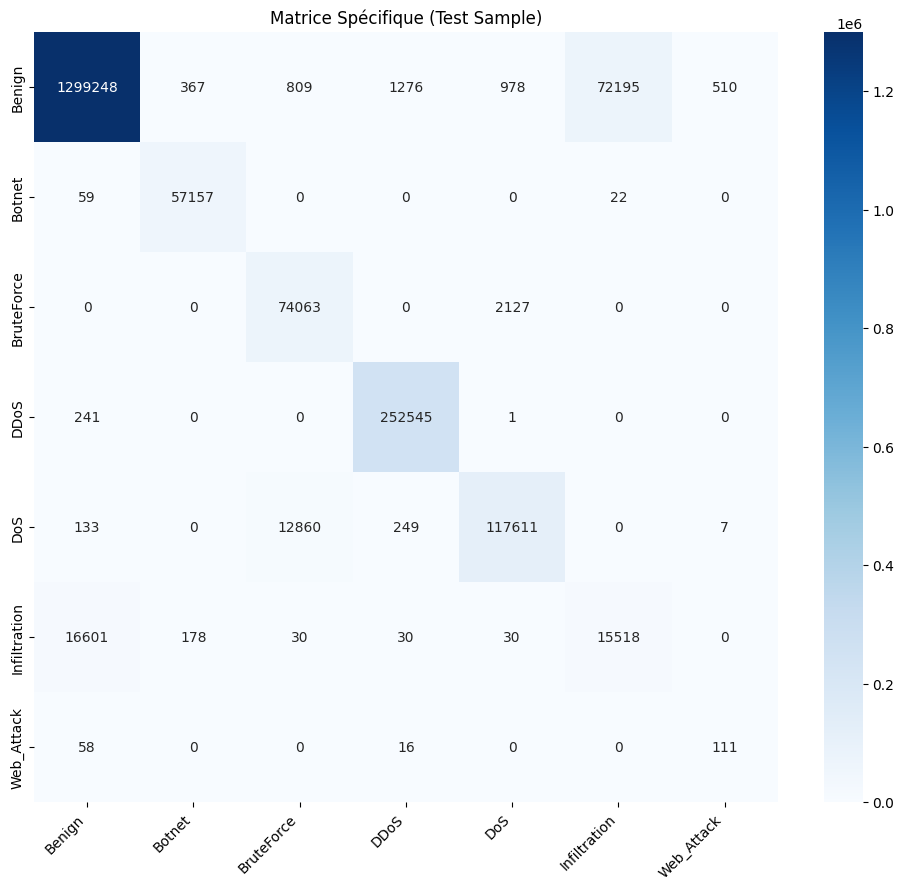


████████████████████████████████████████████████████████████
ROC (BINARY + MULTICLASS) USING NORMALIZED LEVEL-2 LABELS
████████████████████████████████████████████████████████████
Classes used for ROC: ['Benign', 'Botnet', 'BruteForce', 'DDoS', 'DoS', 'Infiltration', 'Web_Attack']


ROC probs (logP per class):   0%|          | 0/30079 [00:00<?, ?it/s]

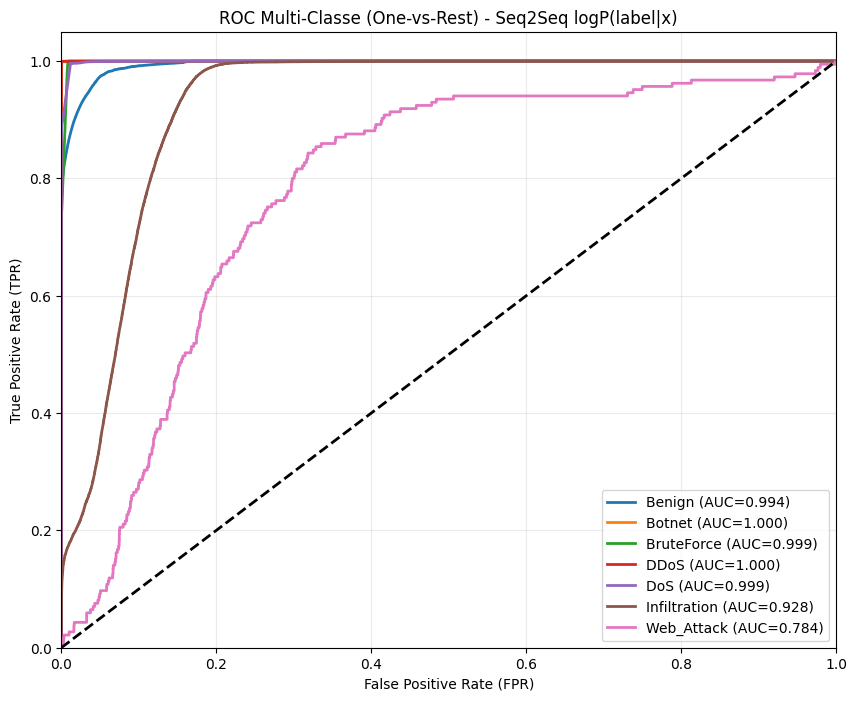

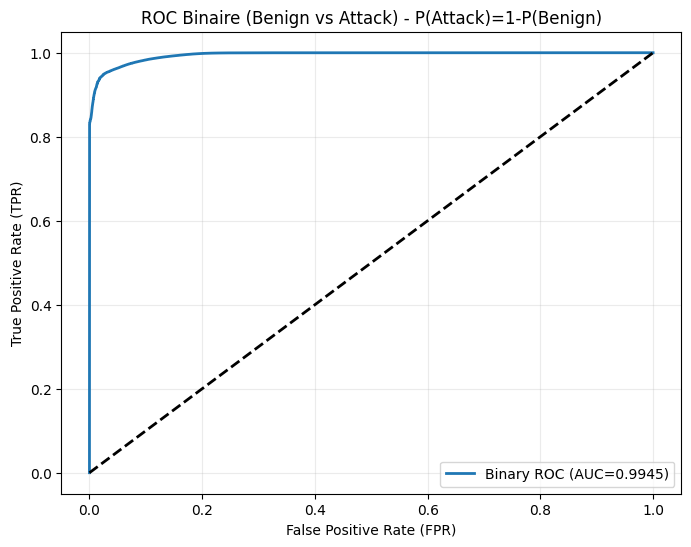


--- Exemple de 'Pensée' de l'Agent ---
Entrée : 80|6|5881080|4|4|97|231.0|97|0|24.25|48.5|231|0|57...
Cible  : Benign
Sortie : Benign


In [10]:
###############################################################
# PHASE 3: ÉVALUATION DE L'AGENT EXPERT (HIERARCHICAL CoT)
#
# Includes:
# - SAMPLE_RATE (fast testing)
# - Confusion matrices + classification reports
# - ROC BINARY (Benign vs Attack)
# - ROC MULTICLASS (One-vs-Rest)
# - Label normalization (fix Web vs Web_Attack, Bot vs Botnet, etc.)
###############################################################

import toml
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np
import random
import torch.nn.functional as F
import time

# --- tqdm (Kaggle friendly) ---
try:
    from tqdm.notebook import tqdm as tqdm_nb
    _TQDM = tqdm_nb
except Exception:
    from tqdm.auto import tqdm as tqdm_auto
    _TQDM = tqdm_auto

# --- 1. CONFIGURATION ---
MODEL_PATH = "/kaggle/input/finalb"
TEST_FILE = "/kaggle/input/toon24/test_full (1).toon"

SAMPLE_RATE = 1.0  # 0.01 = 1% ; 1.0 = full
BATCH_SIZE = 64
MAX_LEN = 256
MAX_OUT = 32
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("========== CONFIG ==========")
print("DEVICE:", DEVICE)
if DEVICE == "cuda":
    try:
        print("GPU:", torch.cuda.get_device_name(0))
    except Exception:
        pass
print("MODEL_PATH:", MODEL_PATH)
print("TEST_FILE:", TEST_FILE)
print("SAMPLE_RATE:", SAMPLE_RATE)
print("BATCH_SIZE:", BATCH_SIZE)
print("============================\n")

# --- 1.B Load model ---
print(f"--- Chargement de l'Agent Expert ---")
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_PATH).to(DEVICE)
model.eval()

# --- 2. Read test data ---
print(f"Lecture du fichier test : {TEST_FILE}...")
with open(TEST_FILE, "r") as f:
    data = toml.load(f)

if "entry" not in data or not isinstance(data["entry"], list) or len(data["entry"]) == 0:
    raise ValueError("❌ Format TOON invalide: clé 'entry' manquante ou vide.")
if "input" not in data["entry"][0] or "target" not in data["entry"][0]:
    raise ValueError("❌ Format TOON invalide: chaque entry doit contenir 'input' et 'target'.")

inputs = [d["input"] for d in data["entry"]]
targets = [d["target"] for d in data["entry"]]

# --- 3. Sampling ---
if SAMPLE_RATE < 1.0:
    print(f"\n⚠️ MODE TEST RAPIDE : Conservation de {SAMPLE_RATE*100:.4f}% des données.")
    total_len = len(inputs)
    num_samples = int(total_len * SAMPLE_RATE)
    num_samples = max(10, num_samples)
    num_samples = min(num_samples, total_len)

    indices = random.sample(range(total_len), num_samples)
    inputs = [inputs[i] for i in indices]
    targets = [targets[i] for i in indices]
    print(f"-> Dataset réduit de {total_len} à {len(inputs)} scénarios.\n")
else:
    print(f"-> {len(inputs)} scénarios de test chargés (100%).")

# --- 4. Inference (generate) ---
preds = []
print("Génération des analyses (Inférence)...")

num_batches = (len(inputs) + BATCH_SIZE - 1) // BATCH_SIZE
pbar_inf = _TQDM(total=num_batches, desc="Inference (generate)", dynamic_ncols=True, mininterval=0.2, leave=True)

t0 = time.time()
for i in range(0, len(inputs), BATCH_SIZE):
    batch_input = inputs[i:i+BATCH_SIZE]
    tok = tokenizer(batch_input, max_length=MAX_LEN, padding="max_length", truncation=True, return_tensors="pt").to(DEVICE)

    with torch.no_grad():
        gen = model.generate(tok["input_ids"], max_length=MAX_OUT)

    decoded = tokenizer.batch_decode(gen, skip_special_tokens=True)
    preds.extend([p.strip() for p in decoded])

    pbar_inf.update(1)
    done = pbar_inf.n
    elapsed = time.time() - t0
    if done > 0:
        pbar_inf.set_postfix({"batches": f"{done}/{num_batches}", "sec/batch": f"{elapsed/done:.2f}"})
pbar_inf.close()

# --- 5. Parse output/targets ---
def parse_cot(text: str):
    parts = text.split(">")
    parts = [p.strip() for p in parts if p.strip()]

    if len(parts) > 0:
        head = parts[0]
        if ("Attack" in head) or ("Attack" in text):
            binary = "Attack"
        elif "Benign" in head:
            binary = "Benign"
        else:
            binary = "Unknown"
    else:
        binary = "Unknown"

    if len(parts) >= 3:
        specific = parts[-1]
    elif len(parts) == 1:
        specific = parts[0]
    else:
        specific = "Unknown"

    return binary, specific

# --- 5.B Label normalization (THIS fixes Web_Attack) ---
LABEL_ALIAS = {
    # if your dataset uses short tokens
    "Web": "Web_Attack",
    "WebAttack": "Web_Attack",
    "Web-Attack": "Web_Attack",
    "Web_Attacks": "Web_Attack",

    "Bot": "Botnet",
    "Bots": "Botnet",

    # keep these as-is (but you can add more aliases if needed)
    "Benign": "Benign",
    "BruteForce": "BruteForce",
    "DDoS": "DDoS",
    "DoS": "DoS",
    "Infiltration": "Infiltration",
}

def normalize_label(x: str) -> str:
    if x is None:
        return "Unknown"
    x = x.strip()
    # normalize obvious formatting issues
    x = x.replace(" ", "_")
    return LABEL_ALIAS.get(x, x)

target_binaries, target_specifics = [], []
for t in targets:
    b, s = parse_cot(t)
    target_binaries.append(normalize_label(b))
    target_specifics.append(normalize_label(s))

pred_binaries, pred_specifics = [], []
for p in preds:
    b, s = parse_cot(p)
    pred_binaries.append(normalize_label(b))
    pred_specifics.append(normalize_label(s))

# --- 6. Reports (Level 1) ---
print("\n" + "█"*60)
print("RAPPORT NIVEAU 1 : DÉTECTION DE MENACES (BINAIRE)")
print("█"*60)
print(classification_report(target_binaries, pred_binaries, zero_division=0))

plt.figure(figsize=(6, 5))
labels_bin = sorted(list(set(target_binaries)))
cm_bin = confusion_matrix(target_binaries, pred_binaries, labels=labels_bin)
sns.heatmap(cm_bin, annot=True, fmt="d", cmap="Greens", xticklabels=labels_bin, yticklabels=labels_bin)
plt.title("Matrice Binaire (Test Sample)")
plt.ylabel("Réalité")
plt.xlabel("Analyse Agent")
plt.show()

# --- 7. Reports (Level 2) ---
print("\n" + "█"*60)
print("RAPPORT NIVEAU 2 : IDENTIFICATION PRÉCISE (Expertise)")
print("█"*60)
unique_labels_lvl2 = sorted(list(set(target_specifics)))
print("Labels seen (Level-2):", unique_labels_lvl2)
print(classification_report(target_specifics, pred_specifics, zero_division=0))

plt.figure(figsize=(12, 10))
cm_spec = confusion_matrix(target_specifics, pred_specifics, labels=unique_labels_lvl2)
sns.heatmap(cm_spec, annot=True, fmt="d", cmap="Blues", xticklabels=unique_labels_lvl2, yticklabels=unique_labels_lvl2)
plt.title("Matrice Spécifique (Test Sample)")
plt.xticks(rotation=45, ha="right")
plt.show()

###############################################################
# 8) ROC for Seq2Seq generative model
###############################################################

def _prepare_label_ids(label_text: str, tokenizer, device):
    ids = tokenizer.encode(label_text, add_special_tokens=False)
    if len(ids) == 0:
        raise ValueError(f"Label '{label_text}' is empty after tokenization.")
    return torch.tensor(ids, dtype=torch.long, device=device)

def _sequence_logprob(model, encoder_inputs, label_ids: torch.Tensor, tokenizer):
    B = encoder_inputs["input_ids"].size(0)
    L = label_ids.size(0)

    start_id = model.config.decoder_start_token_id
    if start_id is None:
        start_id = tokenizer.pad_token_id

    decoder_input = torch.full((B, 1), start_id, dtype=torch.long, device=label_ids.device)
    if L > 1:
        decoder_input = torch.cat([decoder_input, label_ids[:-1].unsqueeze(0).expand(B, L-1)], dim=1)

    with torch.no_grad():
        out = model(
            input_ids=encoder_inputs["input_ids"],
            attention_mask=encoder_inputs["attention_mask"],
            decoder_input_ids=decoder_input
        )
        logits = out.logits

    logp = F.log_softmax(logits, dim=-1)
    target = label_ids.unsqueeze(0).expand(B, L).unsqueeze(-1)
    token_logp = torch.gather(logp, dim=-1, index=target).squeeze(-1)
    return token_logp.sum(dim=1)

def compute_class_probs(inputs_list, class_names, tokenizer, model, device, max_len=256, batch_size=64):
    label_ids = {c: _prepare_label_ids(c, tokenizer, device) for c in class_names}

    all_probs = []
    num_batches = (len(inputs_list) + batch_size - 1) // batch_size
    pbar = _TQDM(total=num_batches, desc="ROC probs (logP per class)", dynamic_ncols=True, mininterval=0.2, leave=True)

    for i in range(0, len(inputs_list), batch_size):
        batch_input = inputs_list[i:i+batch_size]
        enc = tokenizer(batch_input, max_length=max_len, padding="max_length", truncation=True, return_tensors="pt").to(device)

        lp_list = []
        for c in class_names:
            lp_c = _sequence_logprob(model, enc, label_ids[c], tokenizer)
            lp_list.append(lp_c.unsqueeze(1))
        lp_mat = torch.cat(lp_list, dim=1)

        probs = torch.softmax(lp_mat, dim=1).detach().cpu().numpy()
        all_probs.append(probs)

        pbar.update(1)
    pbar.close()

    return np.vstack(all_probs)

print("\n" + "█"*60)
print("ROC (BINARY + MULTICLASS) USING NORMALIZED LEVEL-2 LABELS")
print("█"*60)

valid_idx2 = [i for i, y in enumerate(target_specifics) if y != "Unknown"]
inputs_v = [inputs[i] for i in valid_idx2]
y_v = [target_specifics[i] for i in valid_idx2]

class_names = sorted(list(set(y_v)))
print("Classes used for ROC:", class_names)

if len(class_names) < 2:
    print("⚠️ Impossible de tracer ROC: moins de 2 classes présentes.")
else:
    probs = compute_class_probs(inputs_v, class_names, tokenizer, model, DEVICE, max_len=MAX_LEN, batch_size=BATCH_SIZE)

    # --- MULTICLASS ROC (OvR) ---
    y_true_ids = np.array([class_names.index(y) for y in y_v], dtype=np.int32)
    y_true_bin = label_binarize(y_true_ids, classes=list(range(len(class_names))))

    plt.figure(figsize=(10, 8))
    for c_idx, c_name in enumerate(class_names):
        if y_true_bin[:, c_idx].sum() == 0:
            continue
        fpr, tpr, _ = roc_curve(y_true_bin[:, c_idx], probs[:, c_idx])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f"{c_name} (AUC={roc_auc:.3f})")

    plt.plot([0, 1], [0, 1], "k--", lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate (FPR)")
    plt.ylabel("True Positive Rate (TPR)")
    plt.title("ROC Multi-Classe (One-vs-Rest) - Seq2Seq logP(label|x)")
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.25)
    plt.show()

    # --- BINARY ROC (Benign vs Attack) ---
    if "Benign" not in class_names:
        print("⚠️ Binary ROC skipped: 'Benign' not found.")
    else:
        benign_idx = class_names.index("Benign")
        p_attack = 1.0 - probs[:, benign_idx]
        y_bin = np.array([0 if y == "Benign" else 1 for y in y_v], dtype=np.int32)

        if len(np.unique(y_bin)) < 2:
            print("⚠️ Binary ROC skipped: only one class present.")
        else:
            fpr, tpr, _ = roc_curve(y_bin, p_attack)
            roc_auc = auc(fpr, tpr)

            plt.figure(figsize=(8, 6))
            plt.plot(fpr, tpr, lw=2, label=f"Binary ROC (AUC={roc_auc:.4f})")
            plt.plot([0, 1], [0, 1], "k--", lw=2)
            plt.xlabel("False Positive Rate (FPR)")
            plt.ylabel("True Positive Rate (TPR)")
            plt.title("ROC Binaire (Benign vs Attack) - P(Attack)=1-P(Benign)")
            plt.legend(loc="lower right")
            plt.grid(True, alpha=0.25)
            plt.show()

print("\n--- Exemple de 'Pensée' de l'Agent ---")
if len(inputs) > 0:
    print(f"Entrée : {inputs[0][:50]}...")
    print(f"Cible  : {targets[0]}")
    print(f"Sortie : {preds[0]}")
